# Week 3: Lab Exercises for COMP 432 Machine Learning

In this lab you'll translate mathematics from lecture into practical NumPy code.
Specifically, you'll implement _linear least squares regression_ and _logistic regression_ "from scratch" and compare the results of your own implementations to those of *scikit-learn*, a popular machine learning package.

<span style="color:red"><i>Warning.</i></span> Many of the code cells in this notebook re-use the variable names like `X_tilde`, `y` or `theta`, but assign them different data. If you run cells out of order, you may get unexpected results or errors, so be careful when switching between exercises.

This lab requires a good understanding of NumPy and Matplotlib.
Please complete the previous labs before attempting this one.

**Run the code cell below** to import the required packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.linear_model

# Show fitted estimators as plain text instead of an interactive HTML widget
sklearn.set_config(display="text")

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

## 1. Plotting a 2D function and its gradient

Exercises 1.1&ndash;1.4 ask you to plot a function and its gradient, then optimize it with gradient descent.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.1 &mdash; Evaluate a function on a 2D grid

The Python function below takes another function, `func`, as an argument, and evaluates it on a 2D grid.

In [2]:
def eval_on_grid_unvectorized(func, extent, numsteps):
    """Evaluate func(theta1, theta2) at every point of a 2D grid.

    Args:
        func: Function to evaluate at each grid point.
        extent: Grid extent as (theta1min, theta1max, theta2min, theta2max).
        numsteps: Number of grid steps, the same in each dimension.

    Returns:
        The grid coordinates theta1 and theta2 and the values y, each of shape
        (numsteps, numsteps).
    """
    theta1min, theta1max, theta2min, theta2max = extent
    theta1 = np.empty((numsteps, numsteps))
    theta2 = np.empty((numsteps, numsteps))
    y = np.empty((numsteps, numsteps))
    for i in range(numsteps):
        for j in range(numsteps):
            theta1[i, j] = theta1min + j * (theta1max - theta1min) / (numsteps - 1)
            theta2[i, j] = theta2min + i * (theta2max - theta2min) / (numsteps - 1)
            y[i, j] = func(theta1[i, j], theta2[i, j])
    return theta1, theta2, y

**Run the code cell below** to see an example of its output.

In [3]:
theta1, theta2, y = eval_on_grid_unvectorized(lambda theta1, theta2: theta1 + theta2, (-1, 1, 0, 2), 3)
print("theta1:"); print(theta1)
print("theta2:"); print(theta2)
print("y:");  print(y)

theta1:
[[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
theta2:
[[0. 0. 0.]
 [1. 1. 1.]
 [2. 2. 2.]]
y:
[[-1.  0.  1.]
 [ 0.  1.  2.]
 [ 1.  2.  3.]]


**Write a vectorized version of `eval_on_grid`** in the code cell below. Your code should be fully vectorized, with no for-loops. Consider using [`np.meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) and [`np.linspace`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html).

In [4]:
def eval_on_grid_vectorized(func, extent, numsteps):
    # Your code here. Aim for 4-6 lines.
    theta1min, theta1max, theta2min, theta2max = extent
    theta1 = np.linspace(theta1min, theta1max, numsteps)
    theta2 = np.linspace(theta2min, theta2max, numsteps)
    theta1, theta2 = np.meshgrid(theta1, theta2) # or simply np.meshgrid(np.linspace(theta1min, theta1max, numsteps), np.linspace(theta2min, theta2max, numsteps))
    y = func(theta1, theta2)
    return theta1, theta2, y

**Check your answer** by running the code cell below.

In [5]:
args = (lambda theta1, theta2: theta1 * theta2, (-1, 1, -4, 4), 20)
r1 = eval_on_grid_unvectorized(*args)       # r1 = (theta1, theta2, y) for unvec version
r2 = eval_on_grid_vectorized(*args)         # r2 = (theta1, theta2, y) for vec version
for v1, v2 in zip(r1, r2):
    np.testing.assert_almost_equal(v1, v2)  # check that theta1, theta2, or y matches
print("Correct!")

import timeit
args = (lambda theta1, theta2: theta1**2 + 0.5*theta2, (0, 1, 0, 1), 200)
unvec_time = timeit.timeit("eval_on_grid_unvectorized(*args)", setup="from __main__ import eval_on_grid_unvectorized, args", number=10)
vec_time   = timeit.timeit("eval_on_grid_vectorized(*args)",   setup="from __main__ import eval_on_grid_vectorized, args", number=10)
print(f"Your vectorized code ran {unvec_time / vec_time:.1f}x faster than the original code on a 200x200 grid")

Correct!
Your vectorized code ran 194.2x faster than the original code on a 200x200 grid


<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.2 &mdash; Plot a function as a heatmap

Consider the **[Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function)** with $a=1$ and $b=100$.
$$
f(\theta_1, \theta_2) = (\textstyle1 - \theta_1)^2 + 100(\theta_2 - \theta_1^2)^2
$$

**Write code to compute $f(\theta_1, \theta_2)$**. Your code should work when $\theta_1$ and $\theta_2$ are either numbers or NumPy arrays.

In [6]:
def f(theta1, theta2):
    # Your code here. Aim for 1-3 lines.
    first = (1-theta1)**2
    second = 100*(theta2-theta1**2)**2
    return first + second

**Check your answer** by running the code cell below.

In [7]:
v = f(1.0, 1.0)
assert isinstance(v, float), "Expected float args to give float result"
assert v == 0.0, "Wrong return value for float"
v = f(np.eye(3, 4), np.arange(12).reshape(3, 4))
assert isinstance(v, np.ndarray), "Expected ndarray args to give ndarray result"
np.testing.assert_equal(v, [[100., 101., 401., 901.], [1601., 1600, 3601., 4901.], [6401., 8101., 8100, 12101.]])
print("Correct!")

Correct!


**Write plotting code** to visualize your $f(\theta_1, \theta_2)$ function over the interval $\theta_1 \in [-2, 2]$ and $\theta_2 \in [-1, 3]$. Your plot should look like this:

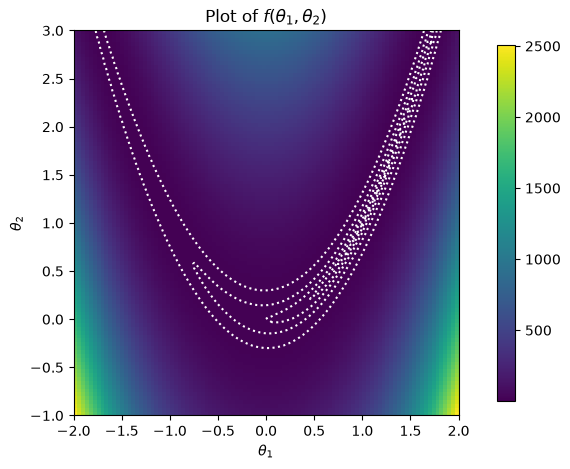

Specifically:

* Use your `eval_on_grid_vectorized` to compute all the grid positions and function values at sufficient resolution.
* Use [`plt.figure`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html) with a `figsize` designed to make the plot twice as wide as it is tall
* Use [`plt.imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) and specify `origin` and `extent` to ensure the function values are plotted at the right positions.
* Use [`plt.colorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html) and specify `fraction=0.046/2` to make its height match the main figure
* Use [`plt.contour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html) and use [`np.logspace`](https://numpy.org/doc/stable/reference/generated/numpy.logspace.html) to plot 5 contours logarithmically spaced between $0.1$ and $10$ inclusive.
* Configure the axis labels and title.

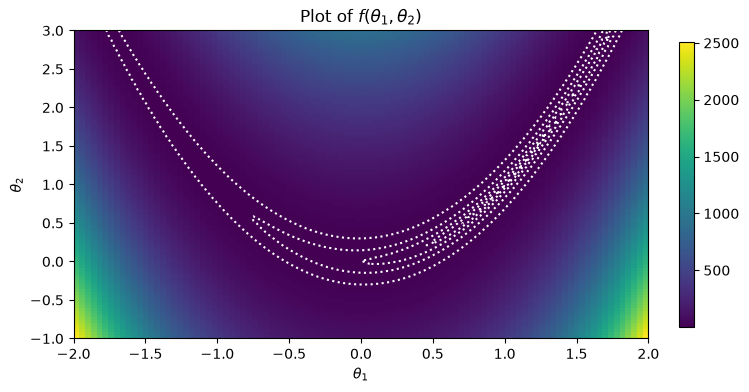

In [8]:
def plot_exercise12():
    # Your code here. Aim for 9-12 lines.
    # 1. Compute the grid of theta1, theta2 values, and y = f(theta1, theta2) for each
    # 2. Plot the y value at each (theta1, theta2)
    # 3. Configure the plot
    extent = (-2, 2, -1, 3)
    numsteps = 100
    theta1, theta2, y = eval_on_grid_vectorized(f, extent, numsteps)
    plt.figure(figsize=(8, 4)) # twice as wide as tall
    plt.imshow(y, extent=extent, origin='lower', aspect='auto') # aspect 'auto' or figsize doesn't do anything
    plt.colorbar(fraction=0.046/2)
    levels = np.logspace(np.log10(0.1), np.log10(10), 5)
    plt.contour(theta1, theta2, y, levels=levels, colors='white', linestyle='dotted')
    plt.xlabel('$\\theta_1$')
    plt.ylabel('$\\theta_2$')
    plt.title('Plot of $f(\\theta_1, \\theta_2$)')
    return


plot_exercise12()

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.3 &mdash; Plot gradients as a vector field

The gradient of $f(\theta_1, \theta_2)$ is a vector-valued function:
$$
\nabla f(\theta_1, \theta_2) = \begin{pmatrix}
\frac{\partial f}{\partial \theta_1}(\theta_1, \theta_2) \\
\frac{\partial f}{\partial \theta_2}(\theta_1, \theta_2) \\
\end{pmatrix}
$$

**Write code to compute $\nabla f(\theta_1, \theta_2)$**. You'll need to use basic calculus (differentiation) to figure out the correct formulas to implement, by yourself. Consider using [`np.stack`](https://numpy.org/doc/stable/reference/generated/numpy.stack.html) to form the final array of gradients.

In [9]:
def f_grad(theta1, theta2):
    """Return both components of the gradient of f, evaluated element-wise.

    Args:
        theta1: Array of first coordinates, of arbitrary shape.
        theta2: Array of second coordinates, of the same shape as theta1.

    Returns:
        The gradient: if theta1 and theta2 have shape (...), the result has shape
        (2, ...), where entry 0 is the first component and entry 1 the second.
    """
    # Your code here. Aim for 1-3 lines.
    # Assuming f(theta1, theta2) = (1-theta1)^2 + 100*(theta2-theta1^2)^2
    partialdOfT1= -2*(1-theta1) - 400*theta1*(theta2-theta1**2)
    partialdOfT2 = 200*(theta2-theta1**2)
    return np.stack([partialdOfT1, partialdOfT2])

**Check your answer** by running the code cell below.

In [10]:
v = f_grad(1.0, 1.0)
assert isinstance(v, np.ndarray), "Expected float args to give ndarray result"
np.testing.assert_equal(v, [0., 0.])
v = f_grad(np.eye(3, 4), np.arange(12).reshape(3, 4))
assert isinstance(v, np.ndarray), "Expected array args to give ndarray result"
assert v.shape == (2, 3, 4), "Result was wrong shape"
np.testing.assert_equal(v, [[[400., -2., -2., -2.], [-2., -1600, -2., -2.], [-2., -2., -3600, -2.]],
                            [[-200., 200., 400., 600.], [800., 800., 1200., 1400.], [1600., 1800., 1800., 2200.]]])
print("Correct!")

Correct!


**Write plotting code** to overlay the gradient $\nabla f(\theta_1, \theta_2)$ over your figure from Exercise 1.2. Your plot should look like this:



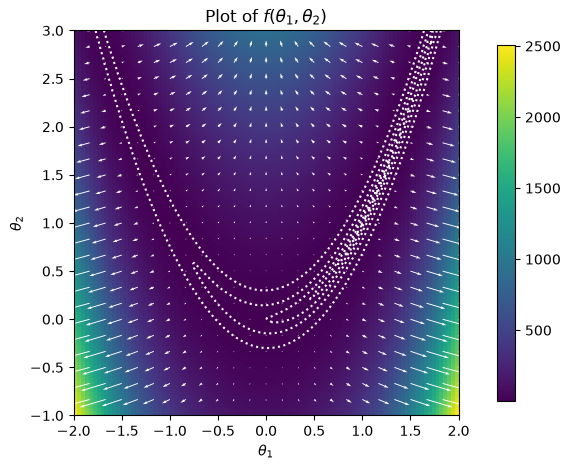

Specifically:

* Use your `eval_on_grid_vectorized` to compute all the grid positions and gradient values at suitable resolution.
* Use [`plt.quiver`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html) to plot the vector field of gradients.

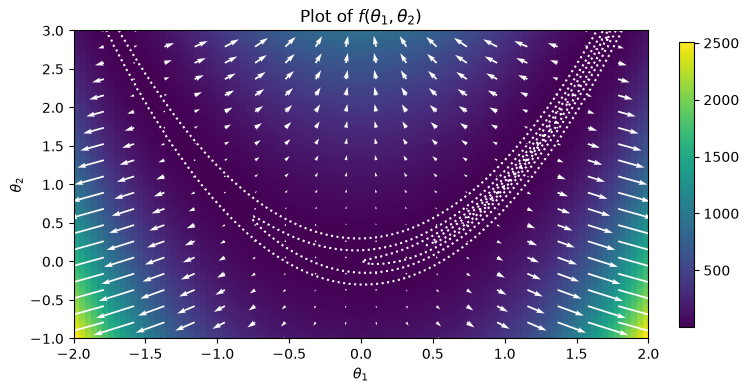

In [11]:
def plot_exercise13():
    plot_exercise12()  # Start with your previous plot

    # Your code here. Aim for 2-4 lines.
    extent = (-2, 2, -1, 3)
    theta1, theta2, y = eval_on_grid_vectorized(f_grad, extent, 20)
    plt.quiver(theta1, theta2, y[0], y[1], color='white')

plot_exercise13()

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.4 &mdash; Gradient descent on a function

Gradient descent (Lecture 2) is an iterative algorithm that repeatedly takes steps in the direction opposite the gradient:

$$
\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_{t} - \eta \nabla f(\boldsymbol{\theta}_{t})
$$

where $\boldsymbol{\theta}_t = (\theta_1, \theta_2)^\top$ is the point reached after $t$ steps.
The step size is scaled by the *learning rate*, which is chosen to be some constant $\eta > 0$.

**Write a function** that runs a specific number of steps of gradient descent on the function $f(\theta_1, \theta_2)$ from Exercise 1.2. To do this, use the `f_grad` function that you wrote for Exercise 1.3.

In [14]:
def gradient_descent_on_f(theta_init, lr, num_steps):
    """Run gradient descent on f, starting from theta_init.

    Args:
        theta_init: Starting point, of shape (2,).
        lr: Learning rate (a scalar).
        num_steps: Number of gradient descent steps to take.

    Returns:
        The point reached after num_steps steps, of shape (2,).
    """
    # Your code here. Aim for 4-5 lines.
    theta_copy = np.array(theta_init, dtype=float) # Make it a float array
    for _ in range(num_steps):
        grad = f_grad(theta_copy[0], theta_copy[1])
        theta_copy -= lr * grad
    return theta_copy

**Check your answer** by running the code cell below

In [15]:
theta = gradient_descent_on_f(np.array([1, 1]), 100.0, 1)
assert isinstance(theta, np.ndarray), "Expected ndarray"
assert np.array_equal(theta, [1, 1]), "Gradient descent shouldn't move away from optimal value!"
theta = gradient_descent_on_f(np.array([1, 0]), 0.0025, 1)
assert np.array_equal(theta, [0., 0.5]), "The first gradient step seems to be wrong!"
theta = gradient_descent_on_f(theta, 0.0001, 3)
assert np.allclose(theta, [0.00061156, 0.470596]), "The gradient seems to be wrong after a few steps!"
print("Correct!")

Correct!


**Plot the path of gradient descent** by running the code cell below. You should see a path of little red 'x' marks that converge near $(\theta_1^*, \theta_2^*)=(1,1)$.


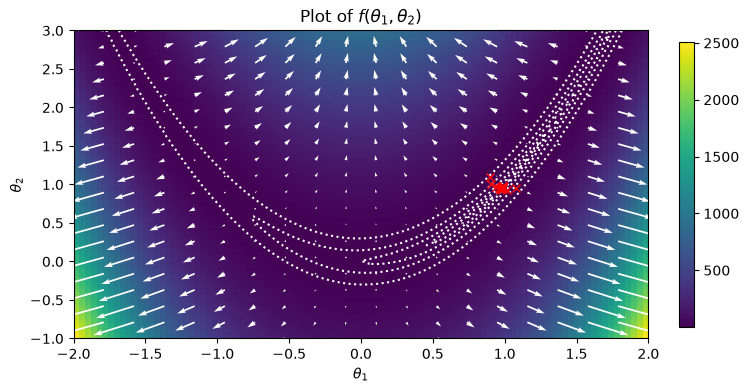

In [16]:
plot_exercise13()  # Plot the vector field first

# Run gradient descent in chunks of 5 steps at a time, plotting the resulting 'theta' after each chunk
lr = 0.002
theta_init = np.array([0.9, 1.1])                                   # Start from initial point (0.9, 1.1)
for num_steps in range(0, 1000, 5):                                 # Repeatedly run gradient descent from the initial point,
    theta = gradient_descent_on_f(theta_init, lr, num_steps)        # eventually running it for 1000 steps.
    plt.plot(*theta, "xr");                                         # Add a little 'x' to the plot to show how far it got.

*Optional:* Advanced students can try adding "momentum" to their implementation of `gradient_descent_on_f`, and then see how it affects the path of optimization. Lecture 2 introduces momentum; helpful visualizations can be found for example in [*Why Momentum Really Works*](https://distill.pub/2017/momentum/).

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

## 2. Linear least squares regression

Exercises 2.1&ndash;2.5 ask you to implement linear least squares regression, and to compare your results to applying the scikit-learn [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 2.1 &mdash; Vectorized code for generating predictions from a basic linear model

Recall from Lecture 3 that a basic linear model has the form:
$$
\hat{y}(\tilde{\mathbf{x}}, \boldsymbol{\theta}) = \tilde{\mathbf{x}}^\top \boldsymbol{\theta}
$$
where
$$
\begin{align}
\tilde{\mathbf{x}} &= \begin{pmatrix} x_1 & \ldots & x_D & 1 \end{pmatrix}^\top\\
\boldsymbol{\theta} &= \begin{pmatrix} w_1 & \ldots & w_D & b \end{pmatrix}^\top
\end{align}
$$

Appending a $1$ to the input turns the bias $b$ into just another weight, so that a single *parameter vector* $\boldsymbol{\theta}$ holds everything the model learns.
Lecture 3 calls $\tilde{\mathbf{x}}$ the *bias-augmented feature vector*.

If both $\tilde{\mathbf{x}}$ and $\boldsymbol{\theta}$ are column vectors, the following Python function would evaluate the linear model $\hat{y}(\tilde{\mathbf{x}}, \boldsymbol{\theta})$ correctly:
```python
def linear_model_predict(x_tilde, theta):
    """Returns a prediction from linear model y(x_tilde, theta) at point x_tilde using parameters theta."""
    return x_tilde.T @ theta   # Return the inner product (dot product) of the two vectors
```
However, we want a version of `linear_model_predict` that vectorizes across many $\tilde{\mathbf{x}}$ simultaneously.
Specifically, given a *bias-augmented data matrix*:

$$
\tilde{\mathbf{X}} = \begin{pmatrix}
\tilde{\mathbf{x}}_1^\top\\
\vdots \\
\tilde{\mathbf{x}}_N^\top
\end{pmatrix}
$$

we want `linear_model_predict` to compute a vector of outputs:

$$
\hat{\mathbf{y}} = \begin{pmatrix}
\tilde{\mathbf{x}}_1^\top \boldsymbol{\theta}\\
\vdots\\
\tilde{\mathbf{x}}_N^\top \boldsymbol{\theta}
\end{pmatrix}
$$

However, if we substitute $\tilde{\mathbf{x}}$ with $\tilde{\mathbf{X}}$ we can no longer use expression `X_tilde.T @ theta`; the matrix $\tilde{\mathbf{X}}^\top \in \mathbb{R}^{(D+1) \times N}$ isn't even the right shape to be on the left-hand side of the product.
Writing vectorized code is full of annoying little problems like this.

**Write a function** that evaluates the linear model in vectorized fashion. Specifically, when given a matrix $\tilde{\mathbf{X}} \in \mathbb{R}^{N \times (D+1)}$ as an argument, you should figure out what mathematical expression would result in the $\hat{\mathbf{y}}\in\mathbb{R}^N$ vector shown above. Hint: the solution is only a small change from `X_tilde.T @ theta`.

In [17]:
def linear_model_predict(X_tilde, theta):
    """Predict with the linear model for every row of X_tilde.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        theta: Parameter vector of shape (D + 1,).

    Returns:
        The predictions, of shape (N,).
    """
    # Your code here. Aim for 1 line.
    return X_tilde @ theta

**Check your answer** by running the code cell below.

In [18]:
theta = np.array([0.5, 2])                             # Parameters corresponding to the 1D line y = 2 + 0.5*x1
X_tilde = np.array([[-3., 1.], [3., 1.], [5., 1.]])    # Evaluate at x1 = -3, 3, 5
y = linear_model_predict(X_tilde, theta)               # Predict y for all X_tilde using theta
assert isinstance(y, np.ndarray), "Expected an ndarray!"
assert np.array_equal(y, [0.5, 3.5, 4.5]), "Wrong predictions!\n%s" % y
try:
    y = linear_model_predict(X_tilde, theta.reshape(-1, 1))
except ValueError:
    raise AssertionError("Your answer works when 'theta' is 1-dimensional, but not when it is a column vector. Try again.")
theta = np.array([0.5, 0.25, 1])                       # Parameters corresponding to the 2D plane y = 1 + 0.5*x1 + 0.25*x2
X_tilde = np.array([[-3., 1., 1.], [3., 0., 1.], [5., -2., 1.]])     # Evaluate at different (x1, x2) points
y = linear_model_predict(X_tilde, theta)               # Predict y for all X_tilde using theta
assert np.array_equal(y, [-0.25, 2.5, 3.0]), "Wrong predictions for 2-dimensional feature space!\n%s" % y
print("Correct!")

Correct!


**Plot several predictions at once** by running the code cell below.

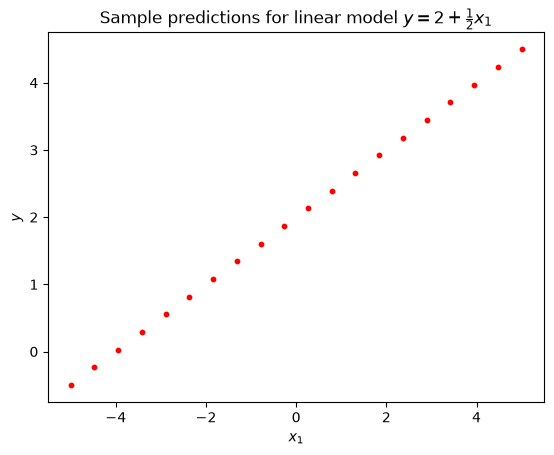

In [19]:
theta = np.array([0.5, 2])                # Parameters corresponding to the 1D line y = 2 + 0.5*x1
x1 = np.linspace(-5, 5, 20)               # A column of x values ranging from [-5, 5]
x0 = np.ones(20)                          # A column of 1s so that the bias theta[-1] gets added
X_tilde = np.column_stack([x1, x0])       # A 20x2 matrix where X_tilde[n,:] is the nth x vector
y = linear_model_predict(X_tilde, theta)  # Evaluate all x values
plt.scatter(x1, y, 10, "r")
plt.xlabel("$x_1$")
plt.ylabel("$y$")
plt.title(r"Sample predictions for linear model $y=2 + \frac{1}{2}x_1$");

<div style="border-bottom: 3px solid black;"></div>

### Exercise 2.2 &mdash; Linear least squares regression by gradient descent

Here you'll implement a 'learning' algorithm for linear least squares regression.
Recall from Lecture 3 that the least squares training objective is the mean squared error:

$$
J(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N (\hat{y}(\tilde{\mathbf{x}}_n, \boldsymbol{\theta}) - y_n)^2
$$

The gradient of this objective is on the slide "Matrix Form: The Gradient" of Lecture 3.
You'll need it.

**Write a function** to implement linear least squares regression by gradient descent. Use the `@` operator (matrix multiplication) in your answer. In your implementation, check for convergence with `eps`: if the absolute value of every component of the gradient is below `eps`, **stop** training.

In [ ]:
def linear_regression_by_gradient_descent(X_tilde, y, theta_init, lr=0.1, num_steps=1000, eps=3e-9):
    """Fit a linear model by gradient descent.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        y: Label vector of shape (N,).
        theta_init: Initial parameter vector of shape (D + 1,).
        lr: Learning rate (a scalar).
        num_steps: Maximum number of gradient descent steps.
        eps: Stop early once every entry of the gradient is smaller than this
            in absolute value.

    Returns:
        The fitted parameter vector, of shape (D + 1,), and the index of the
        last gradient step taken.
    """
    theta = theta_init
    for i in range(num_steps):
        # Your code here. Aim for 4-5 lines.
        predictions = 
        errors = linear_model_predict(X_tilde, theta)- y
        gradient = (2 / X_tilde.shape[0]) * (X_tilde.T @ errors) 
        theta -= lr * gradient
        if np.all(np.abs(gradient) < eps):
            break 
        # Your code ends.
    return theta, i

**Check your answer** by running the code cell below.

In [25]:
X_tilde = np.array([[0.0, 1], [1.0, 1], [2.0, 1]])
y = np.array([4.0, 3.0, 2.0])
max_num_steps = 1000
theta, num_steps = linear_regression_by_gradient_descent(X_tilde, y, np.array([0.0, 0.0]), num_steps=max_num_steps)
assert isinstance(theta, np.ndarray), "Expected ndarray!"
assert theta.shape == (2,), "Wrong shape for final parameters!\n%s" % theta
assert np.allclose(theta, [-1, 4]), "Wrong values for final parameters!\n%s" % theta
assert (num_steps + 1) < max_num_steps, "You should converge before %s steps!" % max_num_steps
print("Correct!")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

<div style="border-bottom: 3px solid black;"></div>

### Exercise 2.3 &mdash; Linear least squares regression by direct solution

As discussed in class, the optimal parameters $\boldsymbol{\theta}^*$ for linear least squares regression can be solved *directly*, rather than iteratively.

**Write a function** to solve linear least squares regression directly. Use Numpy's matrix inverse function [`np.linalg.inv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) in your answer.

In [ ]:
def linear_regression_by_direct_solve(X_tilde, y):
    """Fit a linear model by solving for the optimal parameter vector directly.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        y: Label vector of shape (N,).

    Returns:
        The fitted parameter vector, of shape (D + 1,).
    """
    # Your code here. Aim for 1-2 lines.
    return

In [ ]:
X_tilde = np.array([[0.0, 1], [1.0, 1], [2.0, 1]])
y = np.array([4.0, 3.0, 2.0])
theta = linear_regression_by_direct_solve(X_tilde, y)
assert isinstance(theta, np.ndarray), "Expected ndarray!"
assert theta.shape == (2,), "Wrong shape for final parameters!\n%s" % theta
assert np.allclose(theta, [-1, 4]), "Wrong values for final parameters!\n%s" % theta
print("Correct!")

<div style="border-bottom: 3px solid black;"></div>

### Exercise 2.4 &mdash; Run linear least squares regression and plot the result

For this exercise you'll need to define NumPy arrays that correspond to the following training data:

$$
\tilde{\mathbf{X}} = \begin{pmatrix}
-2.3 & 1\\
-0.2 & 1\\
 1.6 & 1\\
 4.7 & 1
\end{pmatrix}, \quad
\mathbf{y} = \begin{pmatrix}
-1.2 \\
1.4\\
4.3\\
5.4
\end{pmatrix}
$$

**Write code** to create the following plot:

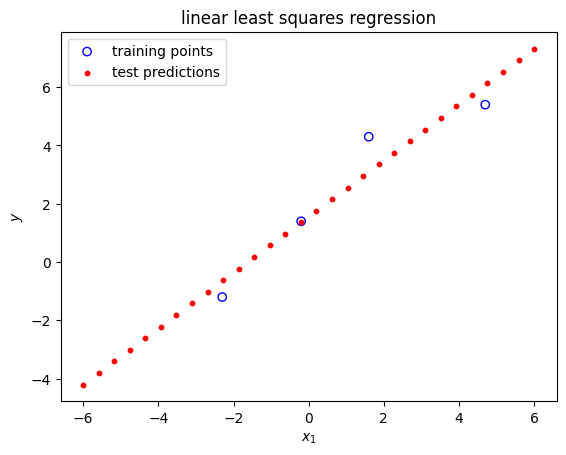


Your code should follow this sequence of steps:
1. Make ndarrays $\tilde{\mathbf{X}}$ and $\mathbf{y}$ that contain the above training set.
2. Plot the training set in blue. Use the $x$ coordinates from the first column of $\tilde{\mathbf{X}}$, ignoring the second column.
3. Run linear least squares regression on $(\tilde{\mathbf{X}}, \mathbf{y})$ to get fitted parameters $\boldsymbol{\theta}$; use your `linear_regression_by_direct_solve` function.
4. Define a "test set" of 30 equally-spaced values of $x$ in range $[-6, 6]$. You will need to build a new matrix $\tilde{\mathbf{X}}_\text{test}$ with the 30 distinct $x$ values in the first column and $1$ in the second column. See how this is done in the last code cell of Exercise 2.1.
5. Predict 30 $y$ values corresponding to the 30 rows of $\tilde{\mathbf{X}}_\text{test}$ by applying a linear model with your fitted parameters $\boldsymbol{\theta}$. Do this with a single call to your `linear_model_predict` function.
6. Plot the predictions on the test set.

In [ ]:
# 1. Define the training set. Aim for 2 lines.


# 2. Plot the training set. Aim for 1 line.


# 3. Run linear least squares regression on the training set to compute 'theta'. Aim for 1 line.


# 4. Define the test set matrix of shape (30,2). Aim for 1-3 lines.


# 5. Use the linear model to make predictions on the test set. Aim for 1 line.


# 6. Plot the test predictions. Aim for 1 line, plus a few lines to configure the plot (axis labels etc).

<div style="border-bottom: 3px solid black;"></div>

### Exercise 2.5 &mdash; Run scikit-learn LinearRegression

The scikit-learn package provides a [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) object to perform linear least squares regression (also known as "ordinary" least squares).

**Write code to fit a LinearRegression model** using the same training matrix $\tilde{\mathbf{X}}$ that you defined as part of Exercise 2.4. There are only two steps:
1. Create the `LinearRegression` object. Use the `fit_intercept=False` option when creating the `LinearRegression` object (see [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)), since the $\tilde{\mathbf{X}}$ matrix already has a column of 1s corresponding to an intercept parameter (the 'bias' parameter).
2. Fit the `LinearRegression` object to the training matrix $\tilde{\mathbf{X}}$ and targets $\mathbf{y}$. Use the object's [`fit`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit) method.

The variable holding a reference to your `LinearRegression` object should be called `linear_model`, so that your answer can be checked.

In [ ]:
# Your code here. Aim for 2 lines.
linear_model = None  # Replace None with your LinearRegression object.

**Check your answer** by running the code cell below.

In [ ]:
assert "linear_model" in globals(), "You didn't create a variable named 'linear_model'!"
assert isinstance(linear_model, sklearn.linear_model.LinearRegression), "Expected a LinearRegression instance!"
assert hasattr(linear_model, "coef_"), "No model coefficients yet! You didn't fit the model to any data!"
assert linear_model.intercept_ == 0.0, "You forgot to disable fitting of the intercept!"
assert np.allclose(linear_model.coef_, [[0.96075085, 1.56228669]]), "The model parameters you learned seem incorrect!"
print("Correct!")

**Plot several LinearRegression model predictions at once** by running the code cell below.

In [ ]:
x1 = np.linspace(-5, 5, 30)                  # A column of x values ranging from [-5, 5]
x0 = np.ones(30)                             # A column of 1s so that the bias parameter gets added
X_tilde_test = np.column_stack([x1, x0])     # A 30x2 matrix where X_tilde_test[n,:] is the nth x vector
y_test = linear_model.predict(X_tilde_test)  # Evaluate all x values
plt.scatter(x1, y_test, 10, "r")
plt.scatter(X_tilde[:, 0], y, edgecolor="b", facecolor="none")
plt.xlabel("$x_1$")
plt.ylabel("$y$")
plt.title("Sample predictions for LinearRegression model");

You can also compare the model's `coef_` attribute (coefficients, i.e. model parameters) to the parameter vector $\boldsymbol{\theta}$ that your own implementation gave from Exercise 2.4 (just use `print(theta)` in your previous answer to see those values).

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black"></div>

## 3. Logistic regression

Exercises 3.1&ndash;3.4 ask you to implement logistic regression, and to compare your results to applying the scikit-learn [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) model.

<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.1 &mdash; Vectorized code for generating predictions from a logistic model

Recall from lecture that the logistic model has the form:
$$
\hat{y}(\tilde{\mathbf{x}}, \boldsymbol{\theta}) = \sigma(\tilde{\mathbf{x}}^\top \boldsymbol{\theta})
$$

where $\tilde{\mathbf{x}}$ and $\boldsymbol{\theta}$ are the same as for Exercise 2.1 and $\sigma(\cdot)$ is the logistic sigmoid function described in Lecture 3.

**Write a function** that evaluates the logistic model in vectorized fashion, just like you did for Exercise 2.1.

In [ ]:
def sigmoid(z):
    """Evaluate the sigmoid function element-wise.

    Args:
        z: Array of arbitrary shape.

    Returns:
        The sigmoid of each entry, of the same shape as z.
    """
    # Your code here. Aim for 1 line.
    return


def logistic_model_predict(X_tilde, theta):
    """Predict with the logistic model for every row of X_tilde.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        theta: Parameter vector of shape (D + 1,).

    Returns:
        The predicted probabilities of class 1, of shape (N,).
    """
    # Your code here. Aim for 1-2 lines.
    return

**Check your answer** by running the code cell below.

In [ ]:
y = sigmoid(np.array([-1., 0., 1.5]))
assert isinstance(y, np.ndarray), "Expected an ndarray!"
assert np.allclose(y, [0.26894142, 0.5, 0.81757448]), "Values from sigmoid() appear to be wrong!"
theta = np.array([1.5, 2])                            # Parameters corresponding to logistic model y = sigmoid(2 + 1.5*x1)
X_tilde = np.array([[-2., 1.], [0., 1.], [2., 1.]])   # Evaluate at x1 = -2, 0, 2
y = logistic_model_predict(X_tilde, theta)            # Predict y for all X_tilde using theta
assert isinstance(y, np.ndarray), "Expected an ndarray!"
assert np.allclose(y, [0.26894142, 0.88079708, 0.99330715]), "Wrong returned!\n%s" % y
try:
    y = logistic_model_predict(X_tilde, theta.reshape(-1, 1))
except ValueError:
    raise AssertionError("Your answer works when 'theta' is 1-dimensional, but not when it is a column vector. Try again.")
theta = np.array([0.5, 0.25, 1])                      # Parameters corresponding to the 2D plane y = 1 + 0.5*x1 + 0.25*x2
X_tilde = np.array([[-3., 1., 1.], [3., 0., 1.], [5., -2., 1.]])     # Evaluate at different (x1, x2) points
y = logistic_model_predict(X_tilde, theta)            # Predict y for all X_tilde using theta
assert np.allclose(y, [0.4378235, 0.92414182, 0.95257413]), "Wrong predictions for 2-dimensional feature space!\n%s" % y
print("Correct!")

**Plot several predictions at once** by running the code cell below.

In [ ]:
theta = np.array([1.5, 2])                            # Parameters corresponding to logistic model y = sigmoid(2 + 1.5*x1)
x1 = np.linspace(-5, 5, 20)                           # A column of x values ranging from [-5, 5]
x0 = np.ones(20)                                      # A column of 1s so that the bias theta[-1] gets added
X_tilde_test = np.column_stack([x1, x0])              # A 20x2 matrix where X_tilde_test[n,:] is the nth x vector
y_test = logistic_model_predict(X_tilde_test, theta)  # Evaluate all x values
plt.scatter(x1, y_test, 10, "r")
plt.xlabel("$x_1$")
plt.ylabel("$y$")
plt.title(r"Sample predictions for logistic model $y=\sigma(2 + \frac{3}{2}x_1)$");

<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.2 &mdash; Logistic regression by gradient descent

Recall from Lecture 3 that the logistic regression training objective is the binary cross-entropy:

$$
J(\boldsymbol{\theta}) = -\frac{1}{N} \sum_{n=1}^N \Big[ y_n \ln\left(\sigma(\boldsymbol{\theta}^\top \tilde{\mathbf{x}}_n)\right) + (1-y_n) \ln \left(1-\sigma(\boldsymbol{\theta}^\top \tilde{\mathbf{x}}_n)\right) \Big]
$$

The gradient of this objective is derived on the slides "Gradient of the Binary Cross-Entropy" of Lecture 3, and reproduced here:

$$
\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N (\sigma(\boldsymbol{\theta}^\top \tilde{\mathbf{x}}_n) - y_n)\, \tilde{\mathbf{x}}_n
$$

**Write a function** to implement logistic regression by gradient descent. Your answer to `logistic_regression_grad` should ideally be fully vectorized (no for-loops), but this may take a while to figure out. If you can't figure out the vectorization, it's OK &mdash; just compute the gradient however you can. Your answer to `logistic_regression` should use your `logistic_regression_grad` function to compute the gradient at each step.

Implementing `logistic_regression_grad` is the hardest exercise in this lab because a vectorized implementation requires using the `@` matrix multiply operator to compute all the $\boldsymbol{\theta}^\top \tilde{\mathbf{x}}$ products, and then combining the residuals with the rows of $\tilde{\mathbf{X}}$, either by reshaping the vector of residuals into a column-vector to use NumPy's broadcasting feature and averaging over a specific axis (over training cases $n=1,\ldots,N$), or with a second matrix multiplication.

In [ ]:
def logistic_regression_grad(X_tilde, y, theta):
    """Return the gradient of the binary cross-entropy.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        y: Label vector of shape (N,).
        theta: Parameter vector of shape (D + 1,).

    Returns:
        The gradient, of shape (D + 1,).
    """
    # Your code here. Aim for 1-3 lines.
    return


def logistic_regression(X_tilde, y, theta_init, lr=0.2, num_steps=500):
    """Fit a logistic model by gradient descent.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        y: Label vector of shape (N,).
        theta_init: Initial parameter vector of shape (D + 1,).
        lr: Learning rate (a scalar).
        num_steps: Number of gradient descent steps to take.

    Returns:
        The fitted parameter vector, of shape (D + 1,), minimizing the binary
        cross-entropy.
    """
    # Your code here. Aim for 4-5 lines.
    return

**Check your answer** by running the code cell below.

In [ ]:
X_tilde = np.array([[-1.0, 1], [1.0, 1], [2.0, 1]])
y = np.array([0.0, 0.0, 1.0])
grad = logistic_regression_grad(X_tilde, y, np.array([1.0, 0.0]))
assert isinstance(grad, np.ndarray), "Expected ndarray from logistic_regression_grad!"
assert grad.shape == (2,), "Expected gradient to have shape (2,) but was %s" % (grad.shape,)
assert np.allclose(grad, [0.07457044, 0.29359903]), "Wrong value for gradient!"
grad = logistic_regression_grad(X_tilde, y, np.array([1.5, -1.0]))
assert np.allclose(grad, [0.10273177, 0.1930382]), "Wrong value for gradient!"
theta = logistic_regression(X_tilde, y, np.array([0.0, 1.0]))
assert isinstance(theta, np.ndarray), "Expected ndarray from logistic_regression!"
assert theta.shape == (2,), "Expected parameter vector theta to have shape (2,) but was %s" % (theta.shape,)
assert np.allclose(theta, [3.39805157, -4.8172062]), "Parameters found by gradient descent seem wrong!"
print("Correct!")

<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.3 &mdash; Run logistic regression on data and plot the result

For this exercise you'll need to define NumPy arrays that correspond to the following training data:

$$
\tilde{\mathbf{X}} = \begin{pmatrix}
-4.2 & 1\\
-2.6 & 1\\
-0.5 & 1\\
 3.1 & 1
\end{pmatrix}, \quad
\mathbf{y} = \begin{pmatrix}
0 \\
0\\
1\\
1
\end{pmatrix}
$$

**Write code** to create the following plot:


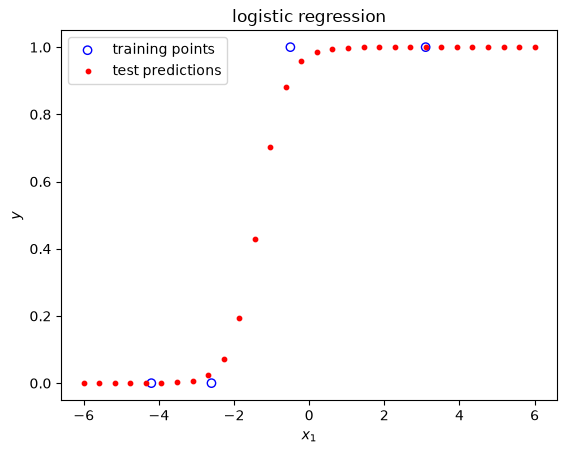

Your code should follow this sequence of steps, which are the same as for Exercise 2.4:
1. Make ndarrays $\tilde{\mathbf{X}}$ and $\mathbf{y}$ that contain the above training set.
2. Plot the training set in blue. Use the $x$ coordinates from the first column of $\tilde{\mathbf{X}}$, ignoring the second column.
3. Run logistic regression on $(\tilde{\mathbf{X}}, \mathbf{y})$ to get fitted parameters $\boldsymbol{\theta}$; use your `logistic_regression` function, starting from $\boldsymbol{\theta}_\text{init} = \begin{pmatrix} 1.0, 0.0 \end{pmatrix}^\top$
4. Define a "test set" of 30 equally-spaced values of $x$ in range $[-6, 6]$. You will need to build a new matrix $\tilde{\mathbf{X}}_\text{test}$ with the 30 distinct $x$ values in the first column and $1$ in the second column.
5. Predict 30 $y$ values corresponding to the 30 rows of $\tilde{\mathbf{X}}_\text{test}$ by applying a logistic model with your fitted parameters $\boldsymbol{\theta}$. Do this with a single call to your `logistic_model_predict` function.
6. Plot the predictions on the test set.

In [ ]:
# 1. Define the training set. Aim for 2 lines.


# 2. Plot the training set. Aim for 1 line.


# 3. Run logistic regression on the training set to get 'theta'. Aim for 1-2 lines.


# 4. Define the test set matrix of shape (30,2). Aim for 1-3 lines.


# 5. Use the logistic model to make predictions on the test set. Aim for 1 line.


# 6. Plot the test predictions. Aim for 1 line, plus a few lines to configure the plot (axis labels etc).

<div style="border-bottom: 3px solid black;"></div>

### Exercise 3.4 &mdash; Run scikit-learn LogisticRegression

The scikit-learn package provides a [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) object to perform logistic regression.

**Write code to fit a LogisticRegression model** using the same training matrix $\tilde{\mathbf{X}}$ that you defined as part of Exercise 3.3. There are only two steps:
1. Create the `LogisticRegression` object. Do not fit an "intercept", and switch the regularization penalty off: scikit-learn controls the penalty through its inverse strength `C`, and `C=np.inf` means no penalty (see [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)).
2. Fit the `LogisticRegression` object to the training matrix $\tilde{\mathbf{X}}$ and targets $\mathbf{y}$. Use the object's [`fit`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit) method.

The variable holding a reference to your `LogisticRegression` object should be called `logistic_model`, so that your answer can be checked.

A tweet regarding the fact that scikit-learn's LogisticRegression object applies regularization (a weight penalty) "by default":


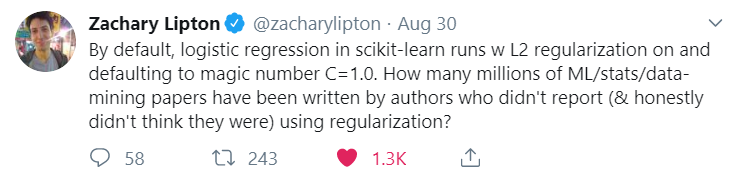

In [ ]:
# Your code here. Aim for 2 lines.
logistic_model = None  # Replace None with your LogisticRegression object.

**Check your answer** by running the code cell below.

In [ ]:
assert "logistic_model" in globals(), "You didn't create a variable named 'logistic_model'!"
assert isinstance(logistic_model, sklearn.linear_model.LogisticRegression), "Expected a LogisticRegression instance!"
assert hasattr(logistic_model, "coef_"), "No model coefficients yet! You didn't fit the model to any data!"
assert logistic_model.intercept_ == 0.0, "You forgot to disable fitting of the intercept!"
assert np.allclose(logistic_model.coef_, [[10.02758805, 16.66568802]]), "The parameters seem incorrect! Not L-BFGS? Used penalty?"
print("Correct!")

Notice that the model parameters (coefficients) found by the `LogisticRegression` are much larger than those found by your gradient descent solver.
The training data are linearly separable, so without a penalty the objective has no minimum: it keeps decreasing as the parameters grow, and every solver stops only once its progress falls below some tolerance.
scikit-learn uses a more powerful optimization algorithm than plain gradient descent, so it gets much further before that happens.
If you increase your `num_steps` argument, your solver will find similarly large coefficients.

**Plot several LogisticRegression predictions at once** by running the code cell below.

In [ ]:
x1 = np.linspace(-6, 6, 30)                          # A column of x values ranging from [-6, 6]
x0 = np.ones(30)                                     # A column of 1s so that the bias parameter gets added
X_tilde_test = np.column_stack([x1, x0])             # A 30x2 matrix where X_tilde_test[n,:] is the nth x vector
y_test = logistic_model.predict_proba(X_tilde_test)  # Evaluate all x values and get two probabilities back (class 0, class 1)
plt.scatter(x1, y_test[:, 1], 10, "r")               # Plot probability of class 1 only
plt.scatter(X_tilde[:, 0], y, edgecolor="b", facecolor="none")
plt.xlabel("$x_1$")
plt.ylabel("$y$")
plt.title("Sample predictions for LogisticRegression model");